In [ ]:
!pip -q install "huggingface_hub>=0.23" pandas numpy scipy matplotlib pyyaml

import os, glob, json, textwrap, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from huggingface_hub import snapshot_download

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

REPO_ID = "ByteDance-Seed/EdgeBench"
TIME_BUDGETS = [2, 4, 6, 8, 10, 12]
MODELS = ["Claude Opus 4.8", "GPT-5.5", "GPT-5.4", "GLM-5.1", "DS-V4-Pro"]

def banner(t):
    print("\n" + "=" * 78 + f"\n  {t}\n" + "=" * 78)

def canon_model(name):
    n = name.lower()
    if "opus" in n:
        return "Claude Opus 4.8"
    if "5.5" in n:
        return "GPT-5.5"
    if "5.4" in n:
        return "GPT-5.4"
    if "glm" in n:
        return "GLM-5.1"
    if "ds-v4" in n or "deepseek" in n:
        return "DS-V4-Pro"
    return name

banner("1. DOWNLOADING DATASET SNAPSHOT")
local_dir = snapshot_download(repo_id=REPO_ID, repo_type="dataset")
print("Snapshot cached at:", local_dir)

In [ ]:
banner("2. LOADING TASK SPECIFICATIONS")

def flatten_task(d):
    work, judge = d.get("work", {}) or {}, d.get("judge", {}) or {}
    rescale = judge.get("rescale", {}) or {}
    return {
        "task_id": d.get("task_id"),
        "name": d.get("name"),
        "category": d.get("category"),
        "base_image": d.get("base_image"),
        "internet": d.get("internet"),
        "game_mode": d.get("game_mode", False),
        "cwd": d.get("cwd"),
        "n_submit": len(d.get("submit_paths", []) or []),
        "submit_paths": ", ".join(d.get("submit_paths", []) or []) or "(interactive)",
        "parser": judge.get("parser") or "(game)",
        "score_dir": judge.get("score_direction", "n/a"),
        "selection": judge.get("selection"),
        "eval_timeout": judge.get("eval_timeout"),
        "rescale_kind": rescale.get("kind"),
        "rescale": rescale,
        "agent_query": work.get("agent_query", "")
    }

records = []
for fp in sorted(glob.glob(os.path.join(local_dir, "*.json"))):
    try:
        with open(fp) as f:
            records.append(flatten_task(json.load(f)))
    except Exception as e:
        print("  ! skipped", os.path.basename(fp), "->", e)

df = pd.DataFrame(records).dropna(subset=["task_id"]).reset_index(drop=True)

print(f"Loaded {len(df)} task specifications.\n")
print(df[["task_id", "category", "base_image", "internet", "rescale_kind"]].head(10).to_string(index=False))

banner("3. BENCHMARK TAXONOMY")
print("Tasks per category:\n", df["category"].value_counts().to_string(), "\n")
print("Runtime (base_image):\n", df["base_image"].value_counts().to_string(), "\n")
print("Judge rescale kinds:\n", df["rescale_kind"].value_counts(dropna=False).to_string(), "\n")
print(f"Tasks needing internet: {int(df['internet'].sum())} | game_mode tasks: {int(df['game_mode'].sum())}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
df["category"].value_counts().plot.barh(ax=ax[0], color="#4C78A8")
ax[0].set_title("Released tasks per category (51)")
ax[0].invert_yaxis()

df["base_image"].value_counts().plot.bar(ax=ax[1], color="#F58518")
ax[1].set_title("Runtime environment")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

banner("3b. ANATOMY OF ONE TASK")
s = df.iloc[0]
print(f"task_id: {s.task_id} | category: {s.category} | base_image: {s.base_image}")
print(f"judge parser: {s.parser} | rescale: {s.rescale_kind} -> {s.rescale}")
print("\n--- agent_query (truncated) ---")
print(textwrap.fill(s.agent_query[:800], width=96))

In [ ]:
banner("4. PARSING THE LEADERBOARD")

readme = open(os.path.join(local_dir, "README.md"), encoding="utf-8").read()

def unescape(x):
    return x.replace("\\_", "_").replace("\\", "").replace("*", "").strip()

def to_float(x):
    x = x.replace("*", "").strip()
    return np.nan if x in ("", "—", "-") else float(x)

def extract_md_tables(md):
    tables, cur = [], []
    for ln in md.splitlines():
        s = ln.strip()
        if s.startswith("|"):
            cur.append([unescape(c) for c in s.strip("|").split("|")])
        elif cur:
            tables.append(cur)
            cur = []
    if cur:
        tables.append(cur)
    return [[r for r in t if not all(set(c) <= set("-: ") for c in r)] for t in tables if t]

tables = extract_md_tables(readme)

def parse_series(cell):
    parts = cell.split("/")
    if len(parts) != len(TIME_BUDGETS):
        return None
    try:
        return [to_float(p) for p in parts]
    except ValueError:
        return None

long_rows = []

for tbl in tables:
    head = tbl[0]
    if head and head[0].lower() == "task" and any("categ" in h.lower() for h in head):
        model_cols = [canon_model(m) for m in head[2:]]
        for row in tbl[1:]:
            if len(row) != len(head):
                continue
            for mname, cell in zip(model_cols, row[2:]):
                series = parse_series(cell)
                if series is None:
                    continue
                for t, sc in zip(TIME_BUDGETS, series):
                    long_rows.append({
                        "task": row[0],
                        "category": row[1],
                        "model": mname,
                        "hours": t,
                        "score": sc
                    })

scores = pd.DataFrame(long_rows)

print(
    f"Parsed {scores['task'].nunique()} tasks x "
    f"{scores['model'].nunique()} models x "
    f"{len(TIME_BUDGETS)} budgets = {len(scores)} cells."
)

agg_time, groups, cur = [], [], []

for tbl in tables:
    head = tbl[0]
    if head and "model" in head[0].lower() and any("@2h" in h for h in head):
        cols = head[1:]
        for row in tbl[1:]:
            if len(row) == len(head):
                rec = {"model": canon_model(row[0])}
                rec.update({c: to_float(v) for c, v in zip(cols, row[1:])})
                cur.append(rec)
        groups.append(cur)
        cur = []

agg51 = pd.DataFrame(groups[1] if len(groups) > 1 else (groups[0] if groups else []))

if not agg51.empty:
    print("\nREADME aggregate (51-task subset):")
    print(agg51.to_string(index=False))

In [ ]:
banner("5. LOG-SIGMOID SCALING LAW (fit on per-task means -> robust)")

def log_sigmoid(t, lo, hi, k, t0):
    return lo + (hi - lo) / (1.0 + np.exp(-k * (np.log(t) - np.log(t0))))

def r2(y, yhat):
    ssr = np.nansum((y - yhat) ** 2)
    sst = np.nansum((y - np.nanmean(y)) ** 2)
    return 1 - ssr / sst if sst > 0 else np.nan

agg = (
    scores.groupby(["model", "hours"])["score"]
    .mean()
    .unstack("hours")
    .reindex(index=MODELS)[TIME_BUDGETS]
)

print("Per-task mean by model & hour:\n", agg.round(2).to_string(), "\n")

t_h = np.array(TIME_BUDGETS, float)
t_dense = np.linspace(2, 12, 200)

fig, ax = plt.subplots(figsize=(9, 5.5))

for color, model in zip(plt.cm.tab10(np.linspace(0, 1, len(MODELS))), MODELS):
    if model not in agg.index:
        continue

    y = agg.loc[model].values.astype(float)

    try:
        popt, _ = curve_fit(
            log_sigmoid,
            t_h,
            y,
            p0=[y[0], y[-1] + 1, 2.0, 4.0],
            bounds=([-50, -50, 1e-2, 0.5], [200, 200, 50, 50]),
            maxfev=200000,
        )

        rr = r2(y, log_sigmoid(t_h, *popt))

        ax.plot(
            t_dense,
            log_sigmoid(t_dense, *popt),
            color=color,
            lw=2,
            label=f"{model} (R²={rr:.3f})",
        )
    except Exception as e:
        print("  fit failed for", model, e)

    ax.scatter(t_h, y, color=color, s=45, zorder=3)

ax.set_xlabel("Interaction time (hours)")
ax.set_ylabel("EdgeBench score (51-task mean)")
ax.set_title("Log-sigmoid scaling of score vs. interaction time")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

piv = scores.pivot_table(
    index=["task", "category"],
    columns=["model", "hours"],
    values="score",
    aggfunc="mean",
)

top = MODELS[0]

uplift = (
    piv[(top, 12)] - piv[(top, 2)]
).groupby("category").mean().sort_values(ascending=False)

print(f"\nMean 2h→12h uplift for {top}, by category:\n", uplift.round(2).to_string())

focus = (
    piv[(top, 12)] - piv[(top, 2)]
).sort_values(ascending=False).head(5).index

fig, ax = plt.subplots(figsize=(9, 5))

for task, cat in focus:
    ax.plot(
        TIME_BUDGETS,
        [piv.loc[(task, cat)][(top, h)] for h in TIME_BUDGETS],
        marker="o",
        label=task[:32],
    )

ax.set_title(f"{top}: per-task learning trajectories (largest gains)")
ax.set_xlabel("Interaction time (hours)")
ax.set_ylabel("Task score")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


  1. DOWNLOADING DATASET SNAPSHOT


Fetching 65 files:   0%|          | 0/65 [00:00<?, ?it/s]

Snapshot cached at: /root/.cache/huggingface/hub/datasets--ByteDance-Seed--EdgeBench/snapshots/47846a4c3669ad447e0ea984833b0d352460c5f9

  2. LOADING TASK SPECIFICATIONS
Loaded 51 task specifications.

                          task_id                       category       base_image  internet  rescale_kind
        ad_placement_optimization     Combinatorial Optimization              cpp     False piecewise_max
        anchorhead_text_adventure Interactive Games & Simulators        python310     False        linear
            ann_vector_search_qps Systems & Software Engineering        python310     False       log_max
           apple_incremental_game     Combinatorial Optimization        python310     False piecewise_max
             arc_compiler_runtime Systems & Software Engineering           python     False        linear
      bipedalwalker_locomotion_rl       Scientific Problems & ML           python     False        linear
          borden_source_inversion       Scientific Probl

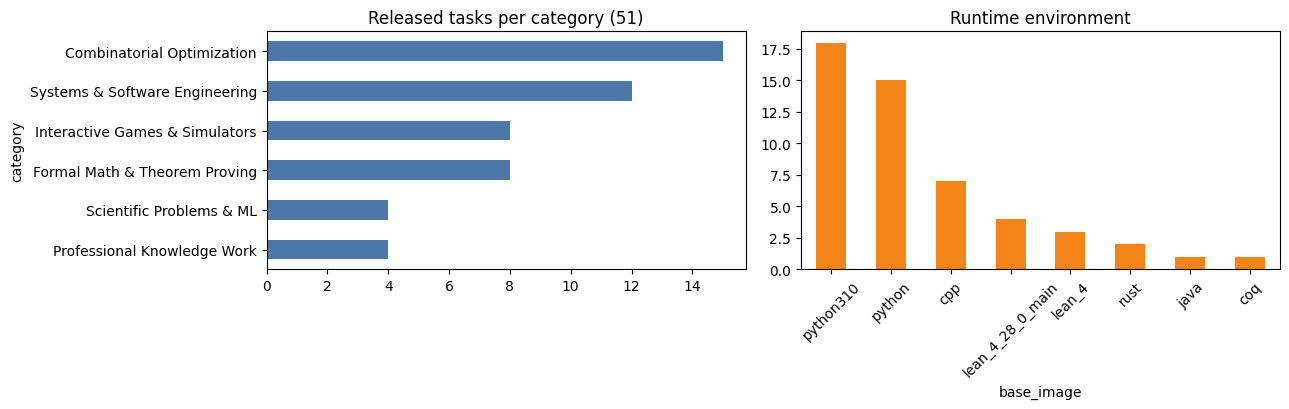


  3b. ANATOMY OF ONE TASK
task_id: ad_placement_optimization | category: Combinatorial Optimization | base_image: cpp
judge parser: score_sum | rescale: piecewise_max -> {'kind': 'piecewise_max', 'baseline': 0.0, 'rank30': 47169682940.0, 'rank1': 49702568341.0, 'super_anchor': 50000000000.0}

--- agent_query (truncated) ---
## Ad Placement Optimization  You need to place rectangular ads for n companies on a 10000x10000
grid.  Each company i wants an ad space containing point (x_i+0.5, y_i+0.5) with area as close
to r_i as possible. Maximize the total satisfaction.  Full problem description, constraints,
scoring formula, and input/output format are in `README.md`.  ## Local Testing Tools  `tools/`
provides an input generator and scoring program. The generator reads a seed file and writes
generated cases into a directory; it does not accept a raw seed directly.  ```bash # Generate
one test input printf '0\n' > /tmp/seeds.txt rm -rf /tmp/ad_cases && mkdir -p /tmp/ad_cases
./tools/bin/gen

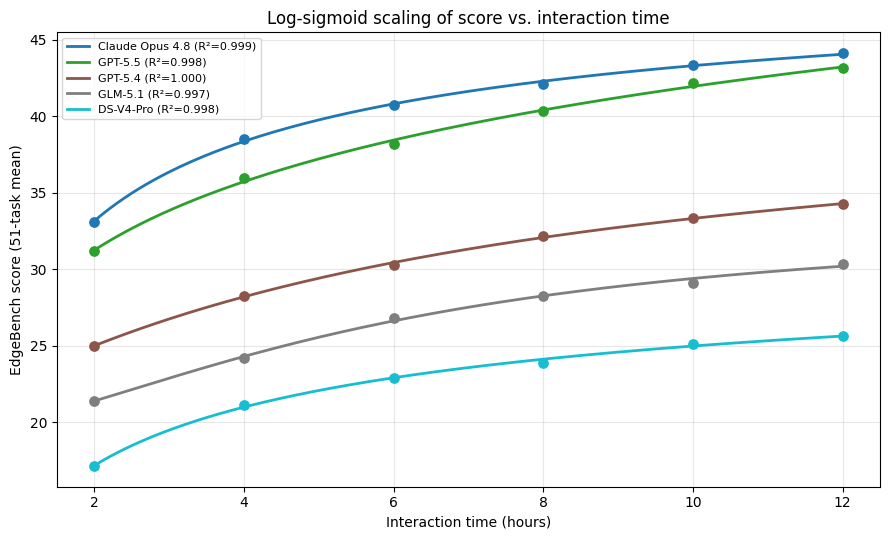


Mean 2h→12h uplift for Claude Opus 4.8, by category:
 category
Formal             18.26
Scientific & ML    15.68
Knowledge          10.87
Optimization        9.31
Systems & SE        8.52
Games               8.20


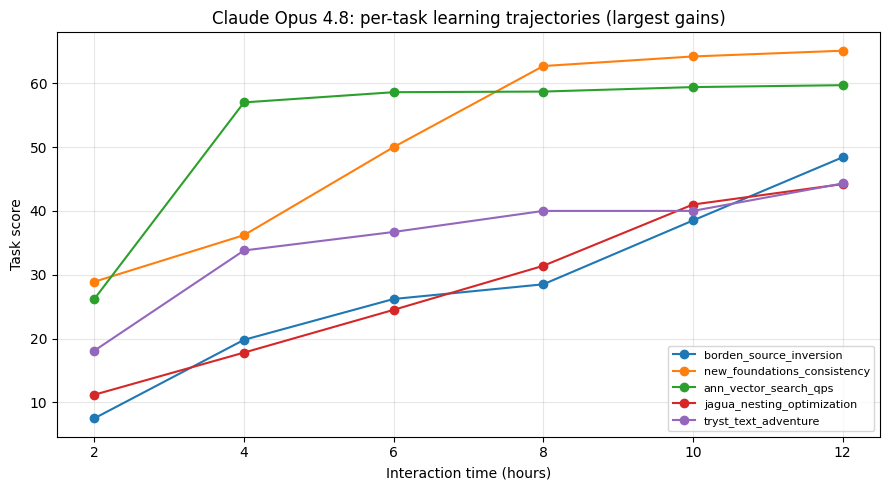


  6. SForge SCORING 'RESCALE' FUNCTIONS

[linear] example: anchorhead_text_adventure
  params: {'kind': 'linear', 'lower': 0.0, 'upper': 100.0}
    raw=        0.00 ->   0.00
    raw=       50.00 ->  50.00
    raw=      100.00 -> 100.00

[piecewise_max] example: ad_placement_optimization
  params: {'kind': 'piecewise_max', 'baseline': 0.0, 'rank30': 47169682940.0, 'rank1': 49702568341.0, 'super_anchor': 50000000000.0}
    raw=             0.0 ->   0.00 (illustrative)
    raw=   47169682940.0 ->  70.00 (illustrative)
    raw=   49702568341.0 ->  99.00 (illustrative)
    raw=   50000000000.0 -> 100.00 (illustrative)

  DONE
Real evaluation runs via the SForge two-container harness:
  https://github.com/ByteDance-Seed/EdgeBench  |  https://bytedance-seed.github.io/EdgeBench/


In [1]:
banner("6. SForge SCORING 'RESCALE' FUNCTIONS")

def rescale_linear(raw, lower, upper):
    return float(np.clip((raw - lower) / (upper - lower) * 100.0, 0, 100))

for kind in ["linear", "piecewise_max"]:
    ex = df[df["rescale_kind"] == kind]

    if ex.empty:
        continue

    row = ex.iloc[0]
    rs = row["rescale"]

    print(f"\n[{kind}] example: {row.task_id}\n  params: {rs}")

    if kind == "linear" and "lower" in rs and "upper" in rs:
        for raw in [rs["lower"], (rs["lower"] + rs["upper"]) / 2, rs["upper"]]:
            print(
                f"    raw={raw:>12.2f} -> "
                f"{rescale_linear(raw, rs['lower'], rs['upper']):6.2f}"
            )
    else:
        xs = [rs["baseline"], rs["rank30"], rs["rank1"], rs["super_anchor"]]
        ys = [0.0, 70.0, 99.0, 100.0]

        for raw in xs:
            print(
                f"    raw={raw:>16.1f} -> "
                f"{float(np.interp(raw, xs, ys)):6.2f} (illustrative)"
            )

banner("DONE")

print("Real evaluation runs via the SForge two-container harness:")
print("  https://github.com/ByteDance-Seed/EdgeBench  |  https://bytedance-seed.github.io/EdgeBench/")